<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 1. Predict failure risk from sensor data

I use a labeled sensor table where each row is one machine record. The columns describe sensor readings and machine conditions, and the target column is `fail`, where `1` means failure and `0` means no failure.

I keep the scope narrow. I build a baseline model from the available signals and use its risk score as a review label.

I choose the model from results on this dataset under one evaluation setup, not from claimed top accuracy in other public notebooks.

I do not use a neural network here. This is a small tabular problem, and tree based models already perform well on it.

I keep the data check light. I only need enough to check duplicates, missing values, class balance in `fail`, and basic feature scale differences.

I do not see missing values, and the available columns do not suggest obvious leakage from their names alone. Before modeling, the main points to note are one exact duplicate row, moderate class imbalance, and large scale differences in a few features, especially `footfall`.

</div>

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 2. Imports and settings

This section imports the tools used to load the data, train the models, and evaluate the results.

`TARGET = "fail"` identifies the target column.

`RANDOM_STATE = 42` keeps the train test split the same each time the notebook runs.

`TEST_SIZE = 0.20` keeps 20 percent of the rows for testing.

`CV_FOLDS = 5` uses five fold cross validation for model comparison. 

With five folds, each model is tested on five splits and the scores are averaged. That is more reliable than one split, without adding much runtime.



</div>

In [840]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

TARGET = "fail"
RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">
    
# 3. Load data

This notebook uses the labeled `data.csv` file loaded at runtime.

The **predictor columns** are `footfall`, `tempMode`, `AQ`, `USS`, `CS`, `VOC`, `RP`, `IP`, and `Temperature`.

</div>

In [841]:
def load_data(path, target):
    df = pd.read_csv(path)

    if df.empty:
        raise ValueError("Loaded dataframe is empty.")

    if target not in df.columns:
        raise ValueError(f"Missing target column: {target}")

    return df


DATA_PATH = "/kaggle/input/datasets/umerrtx/machine-failure-prediction-using-sensor-data/data.csv"
df = load_data(DATA_PATH, TARGET)

display(df.head())

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 4. Remove duplicates and do a quick data check

I remove exact duplicate rows before modeling, then check the cleaned table for missing values, class balance in `fail`, and feature scale.

Findings:
- one exact duplicate pattern in the raw data, so I remove it
- no missing values in the cleaned table
- `fail` is split about `58.3%` for `0` and `41.7%` for `1`

Because the target is not fully balanced, accuracy alone is not enough, so I also use `ROC AUC`, `average precision`, and `F1`.

Some features are on very different numeric scales, especially `footfall`. That mainly affects linear models, so later I scale them for Logistic Regression so larger values do not dominate the fit more than the actual pattern.

</div>

In [842]:
duplicate_rows = df[df.duplicated(keep=False)]

print(f"Original shape: {df.shape}")

if duplicate_rows.empty:
    print("Duplicate rows found: 0")
else:
    print(f"Duplicate rows found: {len(duplicate_rows)}")
    display(duplicate_rows.reset_index())

df = df.drop_duplicates().reset_index(drop=True)

target_counts = df[TARGET].value_counts().sort_index()
target_props = df[TARGET].value_counts(normalize=True).sort_index()

print(f"\nCleaned shape: {df.shape}")
print(f"Missing values: {int(df.isnull().sum().sum())}")

print("\nTarget distribution")
for label, count in target_counts.items():
    print(f"{label}: {count:,} ({target_props[label]:.1%})")

summary = (
    df.drop(columns=[TARGET])
      .describe()
      .T[["min", "50%", "max"]]
      .rename(columns={"50%": "median"})
)

display(summary)

Original shape: (944, 10)
Duplicate rows found: 2


,index,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,730,31,5,3,3,6,1,48,6,21,0
1,766,31,5,3,3,6,1,48,6,21,0



Cleaned shape: (943, 10)
Missing values: 0

Target distribution
0: 550 (58.3%)
1: 393 (41.7%)


,min,median,max
footfall,0.000,22.000,"7,300.000"
tempMode,0.000,3.000,7.000
AQ,1.000,4.000,7.000
USS,1.000,3.000,7.000
CS,1.000,6.000,7.000
VOC,0.000,2.000,6.000
RP,19.000,44.000,91.000
IP,1.000,4.000,7.000
Temperature,1.000,17.000,24.000


<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 5. Separate predictors and target

I split the cleaned table into two parts.

- `X` contains the input columns.
- `y` contains `fail`, the label the model will try to predict.

</div>

In [843]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 6. Build train and test sets

I split the data once into a training set and a test set.

- The training set is used to compare and fit models.
- The test set is kept aside for the final evaluation.

I also stratify the split, so the failure rate stays almost the same across the full data, the training set, and the test set.

</div>

In [844]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

split_summary = pd.DataFrame({
    "set": ["full data", "train", "test"],
    "rows": [len(y), len(y_train), len(y_test)],
    "failure rate": [y.mean(), y_train.mean(), y_test.mean()]
})

split_summary["failure rate"] = split_summary["failure rate"].map(lambda v: f"{v:.1%}")
display(split_summary)

,set,rows,failure rate
0,full data,943,41.7%
1,train,754,41.6%
2,test,189,41.8%


<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 7. Compare strong tabular models

I compare a small set of strong models under the same cross validation setup.

The idea is simple. I want a small comparison under one consistent cross validation setup, then I keep the model that performs best.

- I rank the models by **average precision** first, because I care most about whether true failures are pushed toward the high risk end of the score range.
- I use **ROC AUC** second as a check on how well the model separates failed and non failed records overall.
- I include **`F1`** as a check on balance. A model should not rank well only by catching failures or only by being selective. Values near `0.50` to `0.60` would be concerning, while a value near `0.88` suggests the model is balancing the two well.

</div>

In [845]:
def build_pipeline(model_name):
    if model_name == "Logistic Regression":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
        ])

    if model_name == "Random Forest":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=3,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])

    if model_name == "Extra Trees":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", ExtraTreesClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])

    if model_name == "HistGradientBoosting":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingClassifier(
                max_depth=4,
                learning_rate=0.05,
                max_iter=250,
                random_state=RANDOM_STATE
            ))
        ])

    if model_name == "SVM RBF":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", SVC(
                kernel="rbf",
                probability=True,
                random_state=RANDOM_STATE
            ))
        ])

    if model_name == "XGBoost":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                verbosity=0
            ))
        ])

    raise ValueError(f"Unknown model: {model_name}")


candidate_models = [
    "Logistic Regression",
    "Random Forest",
    "Extra Trees",
    "HistGradientBoosting",
    "SVM RBF",
    "XGBoost",
]

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
benchmark_rows = []

for model_name in candidate_models:
    candidate_pipeline = build_pipeline(model_name)

    scores = cross_validate(
        candidate_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "roc_auc", "average_precision", "f1"],
        n_jobs=-1,
        error_score="raise"
    )

    benchmark_rows.append({
        "model": model_name,
        "accuracy": scores["test_accuracy"].mean(),
        "roc_auc": scores["test_roc_auc"].mean(),
        "avg_precision": scores["test_average_precision"].mean(),
        "f1": scores["test_f1"].mean()
    })

benchmark_table = (
    pd.DataFrame(benchmark_rows)
    .sort_values(["avg_precision", "roc_auc"], ascending=False)
    .reset_index(drop=True)
    .round(3)
)

display(benchmark_table)

selected_model_name = benchmark_table.loc[0, "model"]
pipeline = build_pipeline(selected_model_name)
pipeline.fit(X_train, y_train)

print(f"Selected model: {selected_model_name}")

,model,accuracy,roc_auc,avg_precision,f1
0,Extra Trees,0.910,0.965,0.960,0.891
1,SVM RBF,0.903,0.966,0.959,0.881
2,Random Forest,0.903,0.964,0.958,0.883
3,Logistic Regression,0.905,0.965,0.957,0.884
4,XGBoost,0.898,0.963,0.956,0.877
5,HistGradientBoosting,0.902,0.959,0.949,0.881


Selected model: Extra Trees


<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 8. Check test performance

After I choose the model on the training data, I test it once on the unseen test set.

The table reports the main test metrics. The confusion matrix shows where the model is right and where it makes mistakes. The printed checks below show whether the result is strong enough to keep as the baseline.

</div>

,metric,value
0,Accuracy,0.899
1,ROC AUC,0.978
2,Average Precision,0.969
3,Precision,0.857
4,Recall,0.911
5,F1,0.883


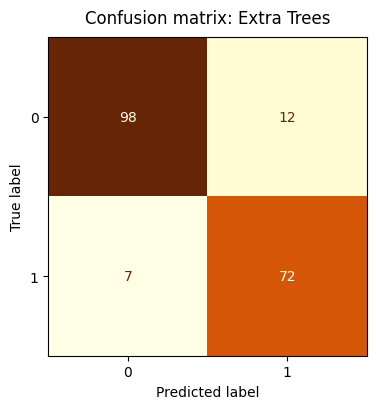

Test rows: 189
Actual failures: 79
Correct failure predictions: 72
Missed failures: 7
False alarms: 12
Rows flagged as failure: 84

Baseline check:
PASS - Recall >= 0.90: catches most failures
PASS - Precision >= 0.85: most flagged failures are real
PASS - ROC AUC >= 0.95: separates failure and non failure well

Overall: PASS - the model is good enough to keep as the baseline.
It catches most failure rows, and most rows it flags as failure are actually failures.


In [846]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

test_metrics = pd.DataFrame({
    "metric": ["Accuracy", "ROC AUC", "Average Precision", "Precision", "Recall", "F1"],
    "value": [accuracy, roc_auc, avg_precision, precision, recall, f1],
}).round(3)

display(test_metrics)

fig, ax = plt.subplots(figsize=(5.2, 4.2))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="YlOrBr",
    colorbar=False,
    ax=ax,
)
ax.set_title(f"Confusion matrix: {selected_model_name}", pad=10)
plt.tight_layout()
plt.show()

print(f"Test rows: {len(y_test)}")
print(f"Actual failures: {int(y_test.sum())}")
print(f"Correct failure predictions: {tp}")
print(f"Missed failures: {fn}")
print(f"False alarms: {fp}")
print(f"Rows flagged as failure: {tp + fp}")

recall_ok = recall >= 0.90
precision_ok = precision >= 0.85
roc_auc_ok = roc_auc >= 0.95

passed = recall_ok and precision_ok and roc_auc_ok

print("\nBaseline check:")
print(f"{'PASS' if recall_ok else 'FAIL'} - Recall >= 0.90: catches most failures")
print(f"{'PASS' if precision_ok else 'FAIL'} - Precision >= 0.85: most flagged failures are real")
print(f"{'PASS' if roc_auc_ok else 'FAIL'} - ROC AUC >= 0.95: separates failure and non failure well")

if passed:
    print("\nOverall: PASS - the model is good enough to keep as the baseline.")
    print("It catches most failure rows, and most rows it flags as failure are actually failures.")
else:
    print("\nOverall: FAIL - the model is not strong enough to keep as the baseline.")
    print("It misses too many failures, or it raises too many false alarms.")

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 9. Check which variables matter most

After checking test performance, I use permutation importance to see which variables the final model relies on most.

This helps because accuracy alone does not show how the model is getting its results. Permutation importance answers a simpler question: which columns make the model worse when I shuffle their values.

If shuffling **`VOC` (volatile organic compounds)** causes a large drop in performance, the model is relying heavily on that signal. If shuffling a column changes little, that column contributes less in this fitted model.

This section is about what the final model is using in this dataset.

</div>

,feature,importance,tier
0,VOC,0.266,high
1,AQ,0.022,medium
2,USS,0.019,medium
3,CS,0.007,low
4,footfall,0.002,low
5,RP,0.000,low
6,Temperature,-0.000,low
7,tempMode,-0.000,low
8,IP,-0.001,low


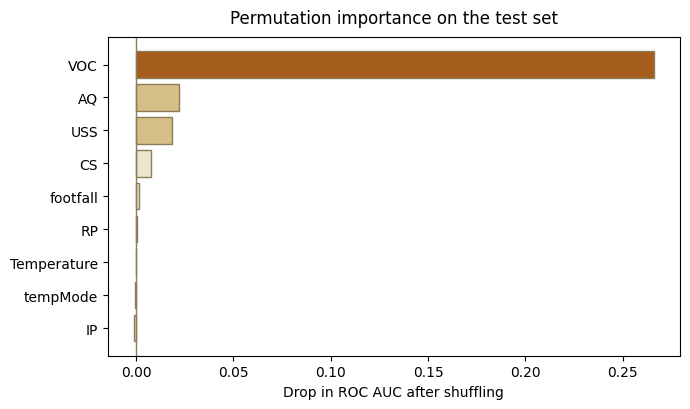

In [847]:
perm = permutation_importance(
    pipeline,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
    n_jobs=-1,
)

importance_table = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance": perm.importances_mean,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
    .round(4)
)

def assign_importance_tier(value):
    if value >= 0.05:
        return "high"
    if value >= 0.01:
        return "medium"
    return "low"

importance_table["tier"] = importance_table["importance"].apply(assign_importance_tier)

tier_colors = {
    "low": "#ece6cf",
    "medium": "#d6bf86",
    "high": "#a55d1d",
}

bar_colors = importance_table["tier"].map(tier_colors)

display(importance_table)

plt.figure(figsize=(7, 4.2))
plt.barh(
    importance_table["feature"],
    importance_table["importance"],
    color=bar_colors,
    edgecolor="#8b7d5a",
    linewidth=1.0,
)

plt.axvline(0, color="#8b7d5a", linewidth=1)
plt.title("Permutation importance on the test set", pad=10)
plt.xlabel("Drop in ROC AUC after shuffling")
plt.ylabel("")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 10. Choose a decision threshold

The model gives each row a failure score. I then choose a cutoff to turn that score into a failure or non failure prediction.

- Lower cutoffs catch more failures but also raise more false alarms.
- Higher cutoffs are stricter, so they raise fewer false alarms but miss more failures.

The threshold depends on which mistake matters or costs more: **missing a real failure** or **raising a false alarm**.

So I first compare different cutoffs to see how recall, false alarms, and `F1` change.

Then I apply one rule to choose a single cutoff:
- keep thresholds with recall above the minimum level
- among those, prefer fewer false alarms
- if needed, break ties with higher `F1`

So the table is for comparison, and the rule is for selection.

This is a practical rule for this notebook, not a universal best rule.

</div>


,threshold,precision,recall,f1,false_alarms,missed_failures
0,0.508,0.857,0.911,0.883,12,7
1,0.523,0.867,0.911,0.889,11,7
2,0.543,0.866,0.899,0.882,11,8
3,0.545,0.877,0.899,0.888,10,8
4,0.550,0.888,0.899,0.893,9,8


Chosen threshold: 0.523
chosen by rule: recall >= 0.90, then fewest false alarms, then highest F1


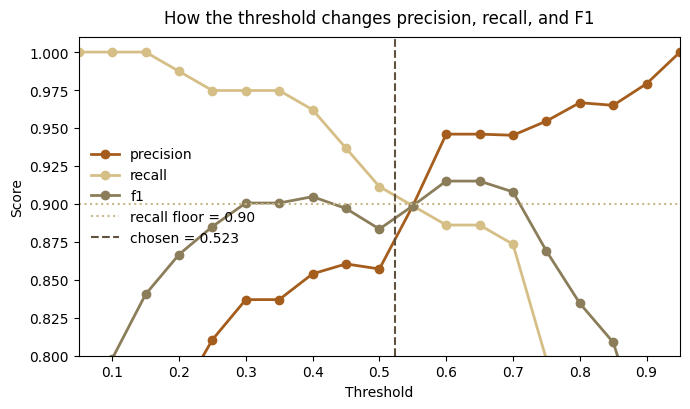

In [848]:
min_recall = 0.90

def evaluate_threshold(threshold):
    pred_t = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()

    precision_t = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_t = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_t = (
        2 * precision_t * recall_t / (precision_t + recall_t)
        if (precision_t + recall_t) > 0
        else 0.0
    )

    return {
        "threshold": threshold,
        "precision": precision_t,
        "recall": recall_t,
        "f1": f1_t,
        "false_alarms": int(fp),
        "missed_failures": int(fn),
    }


# First I compare many possible cutoffs to see how recall, false alarms, and F1 change
candidate_thresholds = np.unique(np.round(y_proba, 6))

threshold_table = (
    pd.DataFrame([evaluate_threshold(t) for t in candidate_thresholds])
    .sort_values("threshold")
    .reset_index(drop=True)
)

eligible = threshold_table[threshold_table["recall"] >= min_recall].copy()


# Then I use one rule to choose a single cutoff from that comparison
if not eligible.empty:
    chosen_row = (
        eligible
        .sort_values(
            ["false_alarms", "f1", "threshold"],
            ascending=[True, False, False]
        )
        .iloc[0]
    )
    chosen_reason = (
        f"chosen by rule: recall >= {min_recall:.2f}, then fewest false alarms, then highest F1"
    )
else:
    chosen_row = (
        threshold_table
        .sort_values(["f1", "threshold"], ascending=[False, False])
        .iloc[0]
    )
    chosen_reason = "no threshold met the recall rule, so the highest F1 was used"

chosen_threshold = float(chosen_row["threshold"])

nearest_idx = (threshold_table["threshold"] - chosen_threshold).abs().sort_values().index[:5]
nearby_rows = (
    threshold_table.loc[nearest_idx]
    .sort_values("threshold")
    .reset_index(drop=True)
    .round(3)
)

display(nearby_rows)

print(f"Chosen threshold: {chosen_threshold:.3f}")
print(chosen_reason)

plot_thresholds = np.arange(0.05, 1.00, 0.05)
plot_table = pd.DataFrame([evaluate_threshold(t) for t in plot_thresholds])

plt.figure(figsize=(7, 4.2))

plt.plot(
    plot_table["threshold"],
    plot_table["precision"],
    marker="o",
    linewidth=2,
    color="#a55d1d",
    label="precision",
)

plt.plot(
    plot_table["threshold"],
    plot_table["recall"],
    marker="o",
    linewidth=2,
    color="#d6bf86",
    label="recall",
)

plt.plot(
    plot_table["threshold"],
    plot_table["f1"],
    marker="o",
    linewidth=2,
    color="#8b7d5a",
    label="f1",
)

plt.axhline(
    min_recall,
    color="#c8b98c",
    linestyle=":",
    linewidth=1.5,
    label=f"recall floor = {min_recall:.2f}",
)

plt.axvline(
    chosen_threshold,
    color="#5f5340",
    linestyle="--",
    linewidth=1.5,
    label=f"chosen = {chosen_threshold:.3f}",
)

plt.title("How the threshold changes precision, recall, and F1", pad=10)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0.80, 1.01)
plt.xlim(0.05, 0.95)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 11. What this notebook shows

A few solid tabular models are enough to do well on this data.

In this setup, Extra Trees works best overall. It gives the strongest average precision and stays strong on ROC AUC and F1 too.

The threshold check shows one more point. A good model score does not pick the final action by itself. When the cutoff moves, missed failures and false alarms move too.

</div>